In [1]:
import pandas as pd
from db import get_conn
from utils.download import get_all_stock
from utils.features import add_features
from utils.signals import add_signals
import warnings
from forecast.lstm_predictor import LSTMPredictorService
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')


In [2]:
# Возьмем для примера акции GOOGLE и на них будим исследовать наши модели
stock_name = "GOOG"
df = get_all_stock()
df = add_features(df)
signals_df = df.loc[stock_name]

# Данный метод добавляет разные сигналы на основе технических индекаторов и пару "идеальных" сигналов на основе истории цены для обучения моделей. 
add_signals(signals_df)

In [3]:
conn = get_conn()
lstm_predictor = LSTMPredictorService(stock_name, conn)
lstm_predictor.deserizalize(signals_df, 0.0)
model_config = lstm_predictor.get_mdoel_config()
first_day = signals_df.index[-1]- relativedelta(months=6) # Последнм днем считаем, последний загруженный в базу данных день
data = signals_df.loc[signals_df.index>=first_day]

In [4]:
data.index

DatetimeIndex(['2024-09-23', '2024-09-24', '2024-09-25', '2024-09-26',
               '2024-09-27', '2024-09-30', '2024-10-01', '2024-10-02',
               '2024-10-03', '2024-10-04',
               ...
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14', '2025-03-17', '2025-03-18', '2025-03-19',
               '2025-03-20', '2025-03-21'],
              dtype='datetime64[ns]', name='stock_date', length=124, freq=None)

In [5]:
sequence_length = model_config.config['seq_length']
offset = model_config.config['offset']
result_df = pd.DataFrame(columns=['close'])
result_df.index.name = 'stock_date'  # Set the index name
for i, test_date in enumerate(data.index):
    pred_close, filtered_close = lstm_predictor.predict(test_date)
    result_df.loc[test_date, 'filtered_close']  = filtered_close
    result_df.loc[test_date, 'pred_close']  = pred_close


<Axes: xlabel='stock_date'>

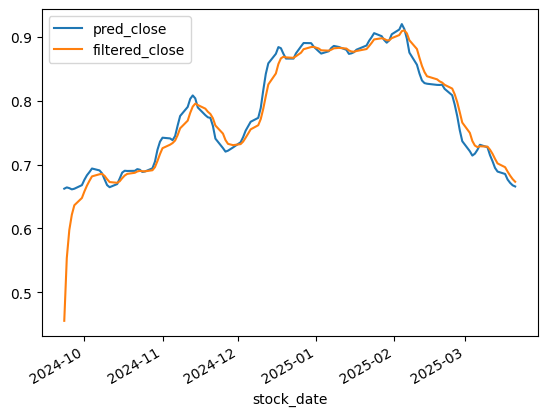

In [6]:
result_df[['pred_close','filtered_close']].plot()

In [ ]:
conn.close()

In [34]:
result_df

,close,pred_close
stock_date,,
2024-09-23,162.699860,0.466435
2024-09-24,163.268555,0.466465
2024-09-25,162.620026,0.466478
2024-09-26,163.458130,0.466485
2024-09-27,164.914810,0.466494
...,...,...
2025-03-17,166.570007,0.466410
2025-03-18,162.669998,0.466400
2025-03-19,166.279999,0.466393
